# Modélisation

Ce notebook construit, optimise et compare plusieurs modèles de classification pour
prédire la décision (acceptation ou rejet) d'un enregistrement. La démarche repose
sur un découpage stratifié, une validation croisée stratifiée pour l'optimisation des
hyperparamètres, la gestion du déséquilibre des classes, et une évaluation fondée sur
le score F1, la précision et le rappel. L'exactitude sur l'entraînement et sur le test
est également comparée afin de détecter un éventuel surapprentissage.

In [1]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

## Chargement des données prétraitées

In [2]:
df = pd.read_csv(r"C:\Users\hp\Desktop\data-quality-bank\data\ml\fct_quality_preprocessed.csv")
print("Dimensions :", df.shape)
df.head()

Dimensions : (505500, 19)


,valeur_metier,rule_id_AUCUNE,rule_id_CARTE_ACTIVE_COMPTE_CLOTURE,rule_id_CLIENT_AGENCE_FERMEE,rule_id_COMPTE_CLIENT_INEXISTANT,rule_id_CONTACT_INVALIDE,rule_id_DIGITAL_CLIENT_INEXISTANT,rule_id_TX_COMPTE_INEXISTANT,rule_id_TX_GAB_SANS_ID,rule_id_TX_NON_GAB_AVEC_ID,table_origine_cartes,table_origine_clients,table_origine_comptes,table_origine_digital_usage,table_origine_transactions,contexte_reporting_ANALYSE_GEOGRAPHIQUE,contexte_reporting_ANALYSE_TRANSACTIONNELLE,contexte_reporting_CAMPAGNE_CONTACT,label
0,0.00,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,1
1,10700.08,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,0
2,6001.62,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,0
3,2103.28,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,0
4,19597.66,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,0


In [3]:
# Séparation des variables explicatives (X) et de la cible (y)
X = df.drop(columns=["label"])
y = df["label"]

print("Répartition de la cible :")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Répartition de la cible :
label
0    476860
1     28640
Name: count, dtype: int64
label
0    94.334322
1     5.665678
Name: proportion, dtype: float64


## Découpage stratifié entraînement / test

Les données sont découpées en un ensemble d'entraînement (80 %) et un ensemble de
test (20 %). Le découpage est **stratifié** afin de préserver la proportion des deux
classes dans chaque ensemble, ce qui est indispensable compte tenu du fort
déséquilibre. L'ensemble de test est mis de côté et ne servira qu'à l'évaluation
finale.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,          # préserve la proportion des classes
    random_state=42
)

print("Entraînement :", X_train.shape, "| Test :", X_test.shape)
print("\nProportion classe positive (rejeté) :")
print(f"  Train : {y_train.mean()*100:.2f} %")
print(f"  Test  : {y_test.mean()*100:.2f} %")

Entraînement : (404400, 18) | Test : (101100, 18)

Proportion classe positive (rejeté) :
  Train : 5.67 %
  Test  : 5.67 %


## Configuration de la validation croisée

Une validation croisée **stratifiée à 5 plis** est utilisée pour l'optimisation des
hyperparamètres. Chaque pli conserve la proportion des classes, garantissant une
évaluation fiable de la classe minoritaire.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Fonction d'évaluation

Cette fonction évalue un modèle en comparant l'**exactitude sur l'entraînement** et
sur le **test** (afin de détecter un éventuel surapprentissage), puis affiche les
métriques adaptées aux données déséquilibrées : précision, rappel et score F1 (sur la
classe positive), ainsi que la matrice de confusion et l'aire sous la courbe ROC. La
classe positive (1) correspond aux enregistrements rejetés.

In [23]:
def evaluer_modele(modele, X_train, y_train, X_test, y_test, nom="Modèle"):
    # Prédictions sur entraînement et test
    y_pred_train = modele.predict(X_train)
    y_pred_test = modele.predict(X_test)

    # Exactitude train vs test (détection du surapprentissage)
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)



    resultats = {
        "Modèle": nom,
        "Accuracy (train)": acc_train,
        "Accuracy (test)": acc_test,
        "Précision": precision_score(y_test, y_pred_test),
        "Rappel": recall_score(y_test, y_pred_test),
        "F1": f1_score(y_test, y_pred_test),
       
    }

    print(f"===== {nom} =====")
    print(f"Accuracy (train) : {acc_train:.4f}")
    print(f"Accuracy (test)  : {acc_test:.4f}")
    print(f"Écart train/test : {acc_train - acc_test:.4f}   (un écart élevé signale du surapprentissage)")
    print(f"Précision        : {resultats['Précision']:.4f}")
    print(f"Rappel           : {resultats['Rappel']:.4f}")
    print(f"F1               : {resultats['F1']:.4f}")
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred_test, target_names=["accepted", "rejected"]))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_test)
    ConfusionMatrixDisplay(cm, display_labels=["accepted", "rejected"]).plot(cmap="Blues")
    plt.title(f"Matrice de confusion — {nom}")
    plt.show()

    return resultats

## Approche de gestion du déséquilibre

Le déséquilibre est traité au **niveau algorithme**, via la pondération des classes
(`class_weight='balanced'` ou équivalent). Cette approche indique au modèle
d'accorder plus d'importance à la classe minoritaire lors de l'entraînement, sans
modifier les données. Une liste pour stocker les résultats de chaque modèle est
initialisée.

In [7]:
resultats_modeles = []

## Modèle 1 — Régression logistique

Modèle linéaire simple servant de référence. La pondération des classes est activée
pour tenir compte du déséquilibre.

Meilleurs hyperparamètres : {'C': 10}
Meilleur F1 (validation croisée) : 0.9488
===== Régression logistique =====
Accuracy (train) : 0.9939
Accuracy (test)  : 0.9937
Écart train/test : 0.0002   (un écart élevé signale du surapprentissage)
Précision        : 0.8997
Rappel           : 0.9997
F1               : 0.9471

Rapport de classification :
              precision    recall  f1-score   support

    accepted       1.00      0.99      1.00     95372
    rejected       0.90      1.00      0.95      5728

    accuracy                           0.99    101100
   macro avg       0.95      1.00      0.97    101100
weighted avg       0.99      0.99      0.99    101100



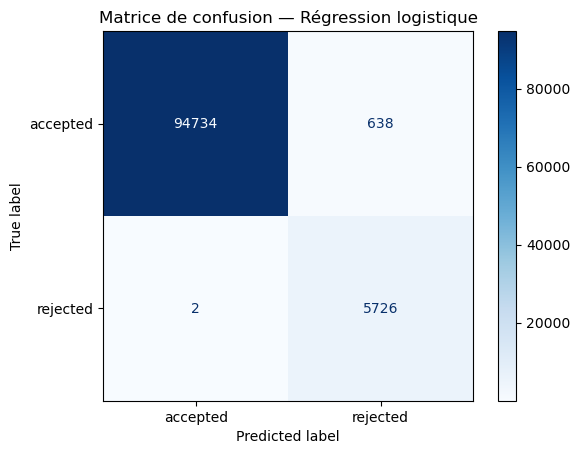

In [24]:
# Grille d'hyperparamètres
param_lr = {
    "C": [0.01, 0.1, 1, 10]
}

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

grid_lr = GridSearchCV(lr, param_lr, cv=cv, scoring="f1", n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_lr.best_params_)
print("Meilleur F1 (validation croisée) :", round(grid_lr.best_score_, 4))

res_lr = evaluer_modele(grid_lr.best_estimator_, X_train, y_train, X_test, y_test, "Régression logistique")
resultats_modeles.append(res_lr)

## Modèle 2 — Naive Bayes

Modèle probabiliste. La variante de Bernoulli est adaptée aux variables binaires
issues du one-hot encoding. Naive Bayes ne dispose pas de pondération des classes ;
le déséquilibre y est indirectement pris en compte par les probabilités a priori.

Meilleurs hyperparamètres : {'alpha': 0.1}
Meilleur F1 (validation croisée) : 0.8949
===== Naive Bayes =====
Accuracy (train) : 0.9867
Accuracy (test)  : 0.9863
Écart train/test : 0.0004   (un écart élevé signale du surapprentissage)
Précision        : 0.8057
Rappel           : 1.0000
F1               : 0.8924

Rapport de classification :
              precision    recall  f1-score   support

    accepted       1.00      0.99      0.99     95372
    rejected       0.81      1.00      0.89      5728

    accuracy                           0.99    101100
   macro avg       0.90      0.99      0.94    101100
weighted avg       0.99      0.99      0.99    101100



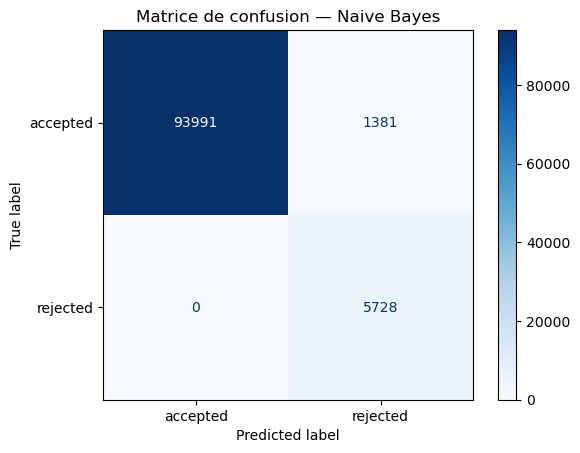

In [25]:
param_nb = {
    "alpha": [0.1, 0.5, 1.0, 2.0]
}

nb = BernoulliNB()

grid_nb = GridSearchCV(nb, param_nb, cv=cv, scoring="f1", n_jobs=-1)
grid_nb.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_nb.best_params_)
print("Meilleur F1 (validation croisée) :", round(grid_nb.best_score_, 4))

res_nb = evaluer_modele(grid_nb.best_estimator_, X_train, y_train, X_test, y_test, "Naive Bayes")
resultats_modeles.append(res_nb)

## Modèle 3 — Forêt aléatoire

Méthode d'ensemble fondée sur le bagging. La pondération des classes est activée.

Meilleurs hyperparamètres : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
Meilleur F1 (validation croisée) : 0.9923
===== Forêt aléatoire =====
Accuracy (train) : 0.9998
Accuracy (test)  : 0.9991
Écart train/test : 0.0007   (un écart élevé signale du surapprentissage)
Précision        : 0.9906
Rappel           : 0.9932
F1               : 0.9919

Rapport de classification :
              precision    recall  f1-score   support

    accepted       1.00      1.00      1.00     95372
    rejected       0.99      0.99      0.99      5728

    accuracy                           1.00    101100
   macro avg       1.00      1.00      1.00    101100
weighted avg       1.00      1.00      1.00    101100



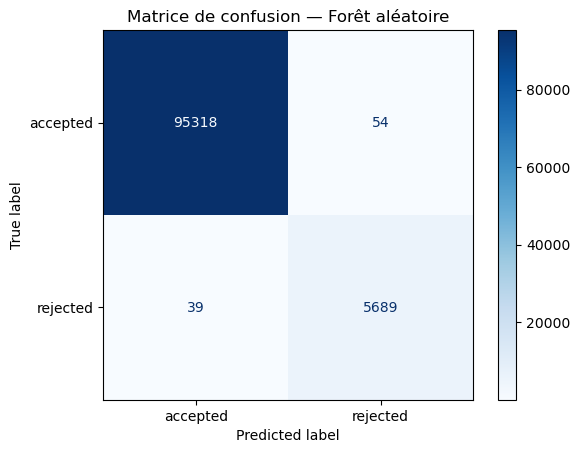

In [26]:
param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5]
}

rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(rf, param_rf, cv=cv, scoring="f1", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_rf.best_params_)
print("Meilleur F1 (validation croisée) :", round(grid_rf.best_score_, 4))

res_rf = evaluer_modele(grid_rf.best_estimator_, X_train, y_train, X_test, y_test, "Forêt aléatoire")
resultats_modeles.append(res_rf)

## Modèle 4 — XGBoost

Méthode d'ensemble fondée sur le boosting. Le déséquilibre est géré par le paramètre
`scale_pos_weight`, fixé au rapport entre le nombre d'exemples négatifs et positifs.

scale_pos_weight : 16.65
Meilleurs hyperparamètres : {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200}
Meilleur F1 (validation croisée) : 0.9822
===== XGBoost =====
Accuracy (train) : 0.9980
Accuracy (test)  : 0.9981
Écart train/test : -0.0001   (un écart élevé signale du surapprentissage)
Précision        : 0.9682
Rappel           : 0.9993
F1               : 0.9835

Rapport de classification :
              precision    recall  f1-score   support

    accepted       1.00      1.00      1.00     95372
    rejected       0.97      1.00      0.98      5728

    accuracy                           1.00    101100
   macro avg       0.98      1.00      0.99    101100
weighted avg       1.00      1.00      1.00    101100



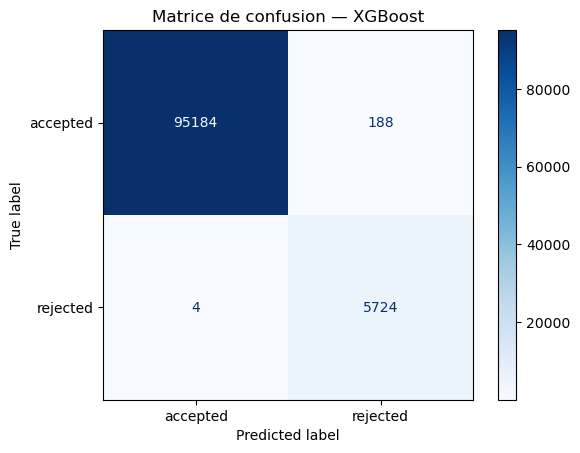

In [27]:
# Rapport négatifs / positifs pour la pondération
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight :", round(ratio, 2))

param_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.1, 0.3]
}

xgb = XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

grid_xgb = GridSearchCV(xgb, param_xgb, cv=cv, scoring="f1", n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_xgb.best_params_)
print("Meilleur F1 (validation croisée) :", round(grid_xgb.best_score_, 4))

res_xgb = evaluer_modele(grid_xgb.best_estimator_, X_train, y_train, X_test, y_test, "XGBoost")
resultats_modeles.append(res_xgb)

## Comparaison des modèles

Les performances des quatre modèles sont regroupées et comparées, en mettant l'accent
sur le score F1, la précision et le rappel, ainsi que sur l'écart entre l'exactitude
d'entraînement et de test.

In [28]:
comparaison = pd.DataFrame(resultats_modeles)
comparaison = comparaison.sort_values("F1", ascending=False).reset_index(drop=True)
comparaison

,Modèle,Accuracy (train),Accuracy (test),Précision,Rappel,F1,AUC
0,Forêt aléatoire,0.999777,0.999080,0.990597,0.993191,0.991893,0.999543
1,Forêt aléatoire,0.999777,0.999080,0.990597,0.993191,0.991893,NaN
2,XGBoost,0.997982,0.998101,0.968200,0.999302,0.983505,0.999973
3,XGBoost,0.997982,0.998101,0.968200,0.999302,0.983505,NaN
4,Régression logistique,0.993885,0.993670,0.899749,0.999651,0.947072,0.999529
5,Régression logistique,0.993885,0.993670,0.899749,0.999651,0.947072,NaN
6,Naive Bayes,0.986746,0.986340,0.805739,1.000000,0.892420,0.997867
7,Naive Bayes,0.986746,0.986340,0.805739,1.000000,0.892420,NaN


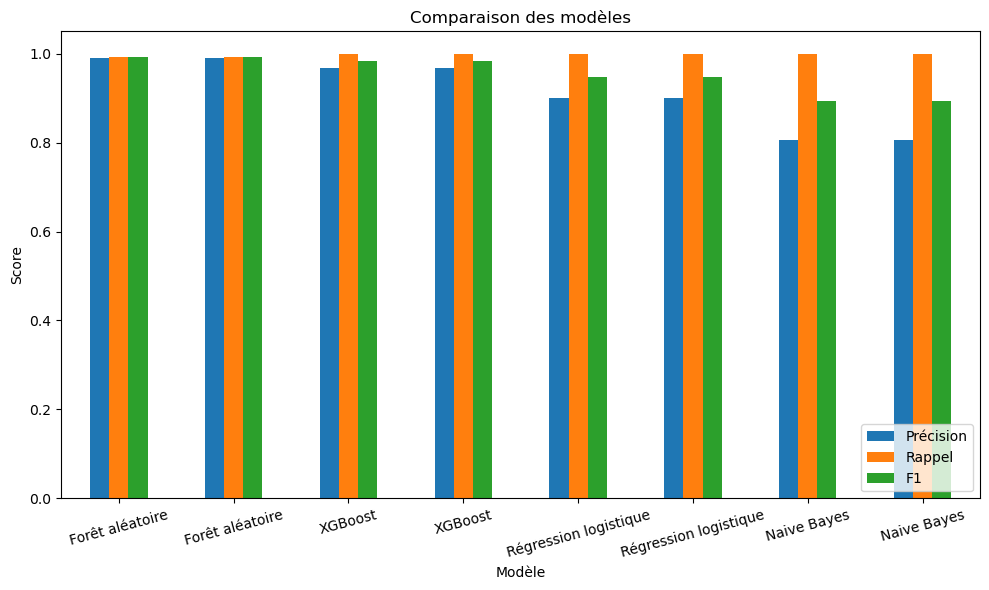

In [29]:
# Visualisation comparative
metriques = ["Précision", "Rappel", "F1"]
comparaison.set_index("Modèle")[metriques].plot(kind="bar", figsize=(10, 6))
plt.title("Comparaison des modèles")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

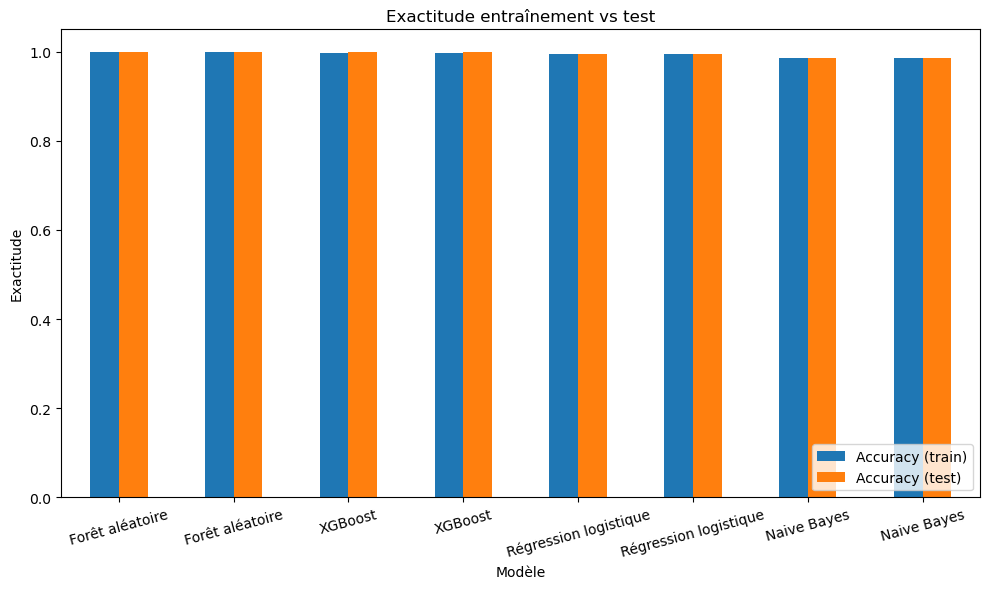

In [30]:
# Comparaison de l'exactitude entraînement vs test (détection du surapprentissage)
comparaison.set_index("Modèle")[["Accuracy (train)", "Accuracy (test)"]].plot(kind="bar", figsize=(10, 6))
plt.title("Exactitude entraînement vs test")
plt.ylabel("Exactitude")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Analyse ciblée sur les zones de gris

Les performances globales élevées s'expliquent par la forte proportion de cas
déterministes (règles dures, enregistrements valides, règles critiques par
contexte). La véritable difficulté du problème se concentre dans les **zones de
gris** : les cas où la décision dépend d'un seuil sur la valeur métier, avec une
part de bruit simulant le jugement humain.

Cette section isole ces zones de gris, **au sein de l'ensemble de test uniquement**,
et y compare les quatre modèles. L'évaluation est menée exclusivement sur des données
que les modèles n'ont jamais vues, afin de mesurer honnêtement leur capacité à
généraliser sur les cas difficiles.

In [31]:
# Identifier les zones de gris DANS L'ENSEMBLE DE TEST uniquement.
# Combinaisons (règle, contexte) dont la décision dépend d'un seuil + bruit.
zones_grises = [
    ("rule_id_TX_GAB_SANS_ID", "contexte_reporting_ANALYSE_TRANSACTIONNELLE"),
    ("rule_id_TX_NON_GAB_AVEC_ID", "contexte_reporting_ANALYSE_TRANSACTIONNELLE"),
    ("rule_id_CLIENT_AGENCE_FERMEE", "contexte_reporting_ANALYSE_GEOGRAPHIQUE"),
    ("rule_id_CARTE_ACTIVE_COMPTE_CLOTURE", "contexte_reporting_ANALYSE_TRANSACTIONNELLE"),
    ("rule_id_DIGITAL_CLIENT_INEXISTANT", "contexte_reporting_ANALYSE_TRANSACTIONNELLE"),
]

# Masque appliqué UNIQUEMENT sur X_test (jamais sur l'entraînement)
masque_gris = pd.Series(False, index=X_test.index)
for col_regle, col_ctx in zones_grises:
    if col_regle in X_test.columns and col_ctx in X_test.columns:
        masque_gris |= (X_test[col_regle] == 1) & (X_test[col_ctx] == 1)

X_test_gris = X_test[masque_gris]
y_test_gris = y_test[masque_gris]

print("Zones de gris dans l'ensemble de test :", len(X_test_gris), "enregistrements")
print("Répartition des labels :")
print(y_test_gris.value_counts())

Zones de gris dans l'ensemble de test : 660 enregistrements
Répartition des labels :
label
1    412
0    248
Name: count, dtype: int64


In [32]:
# Évaluer TOUS les modèles sur les zones de gris du test
resultats_gris = []

for nom, modele in modeles_entraines.items():
    y_pred_g = modele.predict(X_test_gris)
    resultats_gris.append({
        "Modèle": nom,
        "Précision": precision_score(y_test_gris, y_pred_g),
        "Rappel": recall_score(y_test_gris, y_pred_g),
        "F1": f1_score(y_test_gris, y_pred_g),
    })

comparaison_gris = pd.DataFrame(resultats_gris).sort_values("F1", ascending=False).reset_index(drop=True)
comparaison_gris

,Modèle,Précision,Rappel,F1
0,Forêt aléatoire,0.873536,0.905340,0.889154
1,XGBoost,0.693878,0.990291,0.816000
2,Régression logistique,0.646688,0.995146,0.783939
3,Naive Bayes,0.624242,1.000000,0.768657


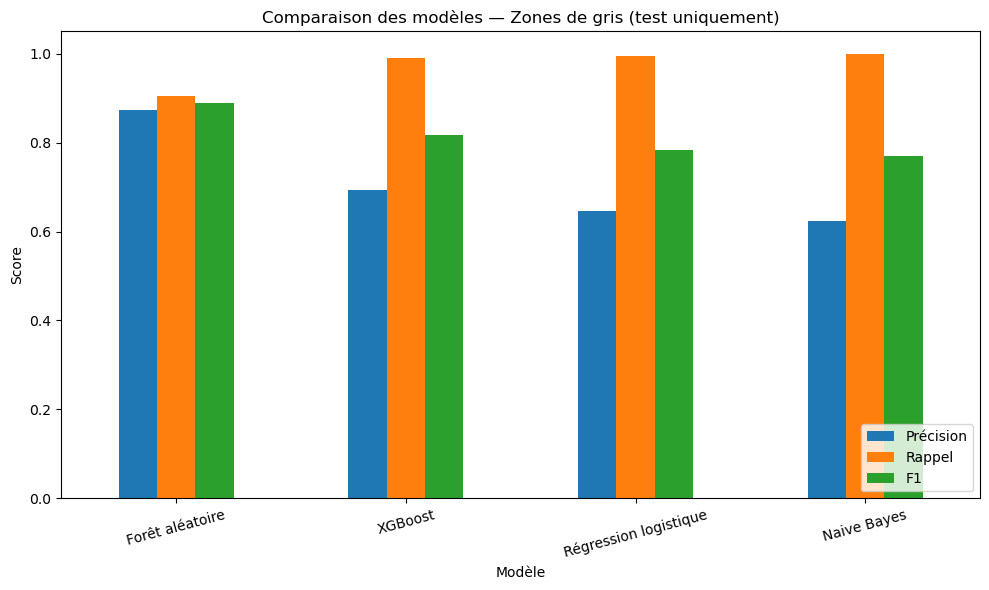

In [33]:
# Visualisation comparative sur les zones de gris
comparaison_gris.set_index("Modèle")[["Précision", "Rappel", "F1"]].plot(kind="bar", figsize=(10, 6))
plt.title("Comparaison des modèles — Zones de gris (test uniquement)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Sélection et sauvegarde du meilleur modèle

Le modèle offrant le meilleur score F1 est retenu et sauvegardé, en vue de son
intégration dans l'application. Les colonnes utilisées lors de l'entraînement sont
également sauvegardées, afin de garantir que les nouveaux enregistrements seront
encodés exactement de la même manière au moment de la prédiction.

In [34]:
import joblib

# Sauvegarder le modèle Forêt aléatoire + les colonnes d'entraînement
joblib.dump(grid_rf.best_estimator_, r"C:\Users\hp\Desktop\data-quality-bank\data\ml\modele_qualite.pkl")
joblib.dump(list(X.columns), r"C:\Users\hp\Desktop\data-quality-bank\data\ml\colonnes_modele.pkl")

print("Modèle et colonnes sauvegardés.")

Modèle et colonnes sauvegardés.
